# Data Input

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Dyslexia_EMNIST_FeatureEngineeringV2.csv")
df.head()

,image_path,file_name,split,folder_category,severity_score,target_class,stroke_density,center_of_mass_x,center_of_mass_y,bounding_box_ratio,stroke_transitions,horizontal_symmetry
0,Dataset\Gambo_EMNIST_Balanced\Test\Corrected\T...,Test_Corrected_1_00017.png,Test,Corrected,1,1,0.086735,11.9706,13.5441,0.4500,1.5714,0.933673
1,Dataset\Gambo_EMNIST_Balanced\Test\Corrected\T...,Test_Corrected_1_00027.png,Test,Corrected,1,1,0.137755,12.2593,12.2963,1.1250,2.0000,0.811224
2,Dataset\Gambo_EMNIST_Balanced\Test\Corrected\T...,Test_Corrected_1_00029.png,Test,Corrected,1,1,0.110969,14.4943,12.3793,0.8000,2.0714,0.859694
3,Dataset\Gambo_EMNIST_Balanced\Test\Corrected\T...,Test_Corrected_1_00036.png,Test,Corrected,1,1,0.122449,12.0417,12.3333,1.6667,1.7857,0.872449
4,Dataset\Gambo_EMNIST_Balanced\Test\Corrected\T...,Test_Corrected_1_00043.png,Test,Corrected,1,1,0.142857,12.2768,12.8839,1.2500,2.3571,0.857143


In [4]:
# Base path in Kaggle
base_path = "/kaggle/input/datasets/adhyatmaaaa/gambo-emnist/Dataset_Gambo_EMNIST (1)/"

# Rebuild image_path
df["image_path"] = (
    base_path + "/" +
    df["split"] + "/" +
    df["folder_category"] + "/" +
    df["file_name"]
)

df.head()

,image_path,file_name,split,folder_category,severity_score,target_class,stroke_density,center_of_mass_x,center_of_mass_y,bounding_box_ratio,stroke_transitions,horizontal_symmetry
0,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00017.png,Test,Corrected,1,1,0.086735,11.9706,13.5441,0.4500,1.5714,0.933673
1,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00027.png,Test,Corrected,1,1,0.137755,12.2593,12.2963,1.1250,2.0000,0.811224
2,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00029.png,Test,Corrected,1,1,0.110969,14.4943,12.3793,0.8000,2.0714,0.859694
3,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00036.png,Test,Corrected,1,1,0.122449,12.0417,12.3333,1.6667,1.7857,0.872449
4,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00043.png,Test,Corrected,1,1,0.142857,12.2768,12.8839,1.2500,2.3571,0.857143


# EDA

In [5]:
df['split'].unique()

array(['Test', 'Train', 'Validation'], dtype=object)

In [6]:
dfv = df[~(df['split']=='Validation')]
dfv['split'].unique()

array(['Test', 'Train'], dtype=object)

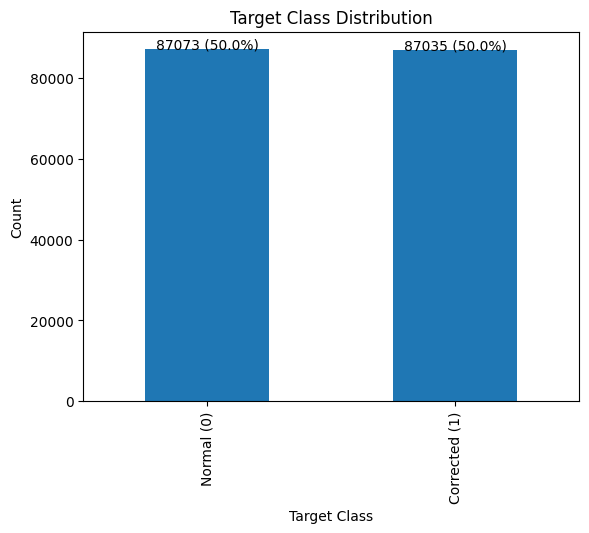

In [7]:
counts = dfv["target_class"].value_counts().sort_index()
percent = counts / counts.sum() * 100

plt.figure()
counts.plot(kind="bar")

for i, v in enumerate(counts):
    plt.text(i, v, f"{v} ({percent[i]:.1f}%)", ha='center')

plt.xlabel("Target Class")
plt.ylabel("Count")
plt.title("Target Class Distribution")

plt.xticks([0, 1], ["Normal (0)", "Corrected (1)"])
plt.show()

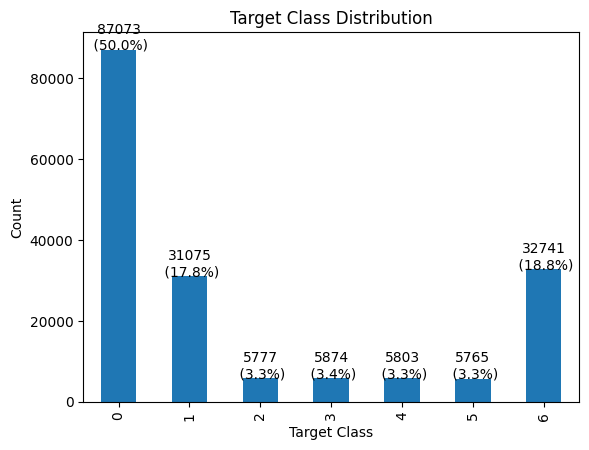

In [8]:
countss = dfv["severity_score"].value_counts().sort_index()
percents = countss / countss.sum() * 100

plt.figure()
countss.plot(kind="bar")

for i, v in enumerate(countss):
    plt.text(i, v, f"{v}\n ({percents[i]:.1f}%)", ha='center')

plt.xlabel("Target Class")
plt.ylabel("Count")
plt.title("Target Class Distribution")

plt.xticks()
plt.show()

In [9]:
dfv[(dfv['severity_score'] == 0) & (dfv['target_class'] == 1)].head(10)

,image_path,file_name,split,folder_category,severity_score,target_class,stroke_density,center_of_mass_x,center_of_mass_y,bounding_box_ratio,stroke_transitions,horizontal_symmetry


In [10]:
import matplotlib.pyplot as plt
from PIL import Image

# Filter your condition
subset = dfv[(dfv['severity_score'] == 0) & (dfv['target_class'] == 1)].head(10)

# Create grid
plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(subset.iterrows()):
    img = Image.open(row['image_path'])
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{row['folder_category']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

In [11]:
dfrm = dfv[~((dfv['severity_score'] == 0) & (dfv['target_class'] == 1))]
dfrm.head(10)

,image_path,file_name,split,folder_category,severity_score,target_class,stroke_density,center_of_mass_x,center_of_mass_y,bounding_box_ratio,stroke_transitions,horizontal_symmetry
0,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00017.png,Test,Corrected,1,1,0.086735,11.9706,13.5441,0.4500,1.5714,0.933673
1,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00027.png,Test,Corrected,1,1,0.137755,12.2593,12.2963,1.1250,2.0000,0.811224
2,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00029.png,Test,Corrected,1,1,0.110969,14.4943,12.3793,0.8000,2.0714,0.859694
3,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00036.png,Test,Corrected,1,1,0.122449,12.0417,12.3333,1.6667,1.7857,0.872449
4,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00043.png,Test,Corrected,1,1,0.142857,12.2768,12.8839,1.2500,2.3571,0.857143
5,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00049.png,Test,Corrected,1,1,0.133929,11.9524,12.8952,1.4286,2.3571,0.798469
6,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00050.png,Test,Corrected,1,1,0.142857,13.7411,14.0625,1.4000,2.5714,0.887755
7,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00076.png,Test,Corrected,1,1,0.167092,13.2061,13.6794,1.0556,2.7143,0.803571
8,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00083.png,Test,Corrected,1,1,0.184949,13.3655,14.0897,0.9524,2.5000,0.803571
9,/kaggle/input/datasets/adhyatmaaaa/gambo-emnis...,Test_Corrected_1_00095.png,Test,Corrected,1,1,0.200255,14.0637,11.8408,1.0000,2.5714,0.834184


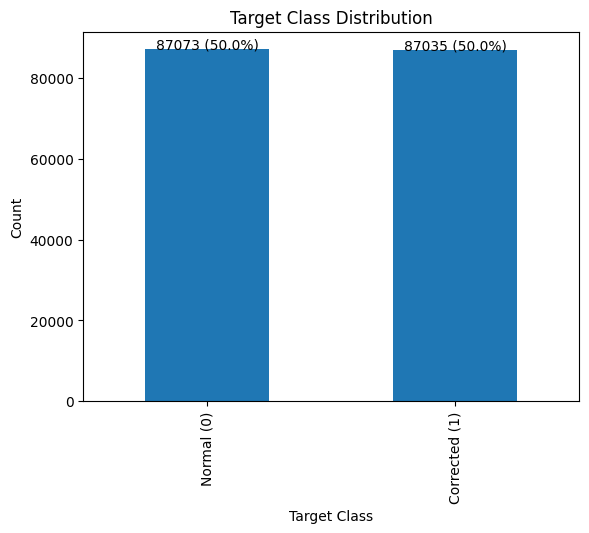

In [12]:
counts = dfrm["target_class"].value_counts().sort_index()
percent = counts / counts.sum() * 100

plt.figure()
counts.plot(kind="bar")

for i, v in enumerate(counts):
    plt.text(i, v, f"{v} ({percent[i]:.1f}%)", ha='center')

plt.xlabel("Target Class")
plt.ylabel("Count")
plt.title("Target Class Distribution")

plt.xticks([0, 1], ["Normal (0)", "Corrected (1)"])
plt.show()

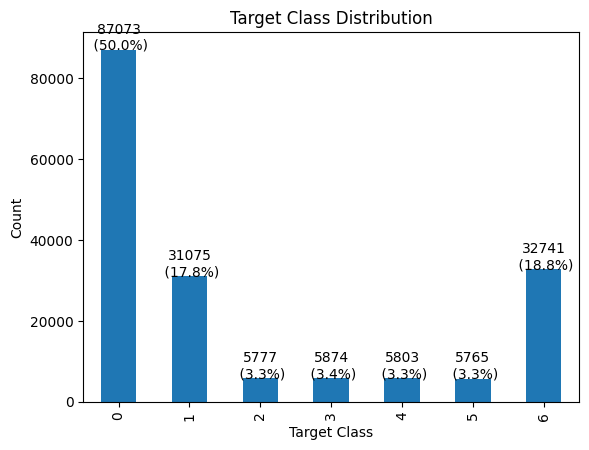

In [13]:
countss = dfrm["severity_score"].value_counts().sort_index()
percents = countss / countss.sum() * 100

plt.figure()
countss.plot(kind="bar")

for i, v in enumerate(countss):
    plt.text(i, v, f"{v}\n ({percents[i]:.1f}%)", ha='center')

plt.xlabel("Target Class")
plt.ylabel("Count")
plt.title("Target Class Distribution")

plt.xticks()
plt.show()

# Image Input

In [5]:
train_df = df[df['split']=='Train']
val_df = df[df['split']=='Validation']
test_df = df[df['split']=='Test']

In [6]:
import tensorflow as tf


IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
 
def make_dataset(df):
    """
    df must have columns: image_path, severity_score, dyslexia_label (0/1)
    Returns a tf.data.Dataset yielding (image, {"severity": ..., "dyslexia": ...})
    """
    paths     = df["image_path"].values
    severity  = df["severity_score"].values.astype("float32")
    dyslexia  = df["target_class"].values.astype("float32")
 
    ds = tf.data.Dataset.from_tensor_slices((paths, severity, dyslexia))
 
    def load_image(path, sev, dys):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = img / 255.0
        return img, {"severity": sev, "dyslexia": dys}
 
    ds = (ds
          .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))
    return ds

train_ds = make_dataset(train_df).shuffle(1000)
val_ds   = make_dataset(val_df)
test_ds = make_dataset(test_df)

2026-05-20 10:30:05.678255: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779273005.867212      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779273005.922475      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779273006.362970      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779273006.363018      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779273006.363021      57 computation_placer.cc:177] computation placer alr

# Model

## Sequential

In [7]:
import tensorflow as tf

K = tf.keras
L = K.layers
M = K.models

In [20]:
import tensorflow as tf

def mish(x):
    return x * tf.math.tanh(tf.math.softplus(x))

# Optional: register so you can use it by name
tf.keras.utils.get_custom_objects().update({'mish': L.Activation(mish)})

In [32]:
model = M.Sequential([
    L.Conv2D(256, (3,3), padding='same', input_shape=(128,128,3)),
    L.BatchNormalization(),
    L.Activation('gelu'),
    L.MaxPooling2D(),

    L.Conv2D(128, (3,3), padding='same'),
    L.BatchNormalization(),
    L.Activation('gelu'),
    L.MaxPooling2D(),
    L.Dropout(0.2),

    L.Conv2D(64, (3,3), padding='same'),
    L.BatchNormalization(),
    L.Activation('relu'),
    L.AveragePooling2D(pool_size=(2,2)),

    L.GlobalAveragePooling2D(),
    L.Dense(32),
    L.BatchNormalization(),
    L.Activation('relu'),
    L.Dropout(0.5),

    # REGRESSION OUTPUT
    L.Dense(1, activation='relu')   # or 'relu' if severity >= 0
])

model.compile(
    optimizer='adamW',  # safer than 'adamW' unless explicitly imported
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 128, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 128, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 16, 16, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,033 (1.45 MB)

 Trainable params: 379,073 (1.45 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    batch_size = 32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    # callbacks=[reduce_lr, checkpoint]
)

Epoch 1/50
5776/5776 ━━━━━━━━━━━━━━━━━━━━ 377s 62ms/step - loss: 3.2447 - mae: 1.1100 - val_loss: 6.7761 - val_mae: 1.4514 - learning_rate: 0.0010
Epoch 2/50
5776/5776 ━━━━━━━━━━━━━━━━━━━━ 365s 61ms/step - loss: 1.7087 - mae: 0.7523 - val_loss: 2.5114 - val_mae: 0.8871 - learning_rate: 0.0010
Epoch 3/50
5776/5776 ━━━━━━━━━━━━━━━━━━━━ 366s 61ms/step - loss: 1.2864 - mae: 0.6288 - val_loss: 43.0793 - val_mae: 6.1187 - learning_rate: 0.0010
Epoch 4/50
5776/5776 ━━━━━━━━━━━━━━━━━━━━ 366s 61ms/step - loss: 1.1230 - mae: 0.5799 - val_loss: 0.9279 - val_mae: 0.5073 - learning_rate: 0.0010
Epoch 5/50
5776/5776 ━━━━━━━━━━━━━━━━━━━━ 369s 62ms/step - loss: 1.0182 - mae: 0.5447 - val_loss: 6.8611 - val_mae: 1.4529 - learning_rate: 0.0010
Epoch 6/50
5776/5776 ━━━━━━━━━━━━━━━━━━━━ 373s 63ms/step - loss: 0.9367 - mae: 0.5219 - val_loss: 0.7475 - val_mae: 0.4502 - learning_rate: 0.0010
Epoch 7/50
5776/5776 ━━━━━━━━━━━━━━━━━━━━ 372s 63ms/step - loss: 0.8848 - mae: 0.5034 - val_loss: 0.8271 - val_mae: 0

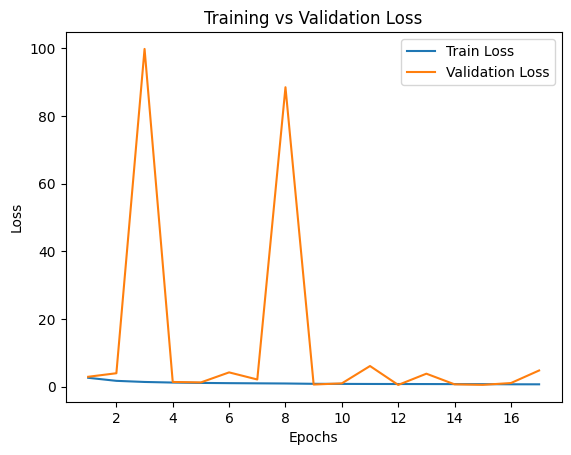

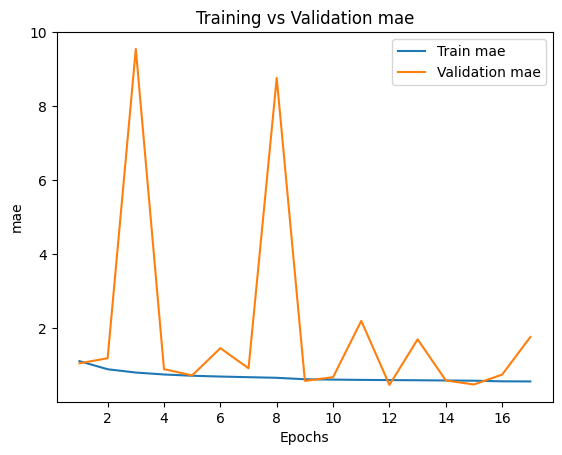

In [31]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['mae']
val_acc = history.history['val_mae']


import matplotlib.pyplot as plt

epochs = range(1, len(train_loss) + 1)

# LOSS PLOT
plt.figure()
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# ACCURACY PLOT
plt.figure()
plt.plot(epochs, train_acc, label='Train mae')
plt.plot(epochs, val_acc, label='Validation mae')
plt.xlabel('Epochs')
plt.ylabel('mae')
plt.title('Training vs Validation mae')
plt.legend()
plt.show()

## Model Sub-Classing

In [22]:
class StrokeFeatureLayer(L.Layer):
    """
    Stroke-aware feature extractor.
    Uses depthwise-separable convolution (faster than vanilla Conv2D)
    then adds a learned Sobel-inspired edge gate to emphasise writing strokes.
    """
 
    def __init__(self, filters: int, kernel_size: int = 3, **kwargs):
        super().__init__(**kwargs)
        self.filters     = filters
        self.kernel_size = kernel_size
 
        # Depthwise separable = depthwise + pointwise (faster & fewer params)
        self.dw_conv  = L.DepthwiseConv2D(kernel_size, padding="same", use_bias=False)
        self.pw_conv  = L.Conv2D(filters, 1, padding="same", use_bias=False)
        self.bn       = L.BatchNormalization()
        self.act      = L.Activation("gelu")
 
        # Stroke gate: learns how much edge signal to mix in
        self.edge_gate = self.add_weight(
            name="edge_gate", shape=(1,), initializer="zeros", trainable=True
        )
 
    def call(self, x, training=False):
        # Depthwise-separable path
        out = self.dw_conv(x)
        out = self.pw_conv(out)
        out = self.bn(out, training=training)
 
        # Approximate horizontal + vertical Sobel on input (grayscale-collapsed)
        gray    = tf.reduce_mean(x, axis=-1, keepdims=True)          # (B,H,W,1)
        sobel_h = tf.image.sobel_edges(gray)[..., 0]                 # horizontal
        sobel_v = tf.image.sobel_edges(gray)[..., 1]                 # vertical
        edges   = tf.sqrt(sobel_h**2 + sobel_v**2 + 1e-6)           # magnitude
        edges   = tf.repeat(edges, self.filters, axis=-1)            # broadcast to filters
 
        # Gated addition of edge signal
        out = out + tf.sigmoid(self.edge_gate) * edges
        return self.act(out)
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"filters": self.filters, "kernel_size": self.kernel_size})
        return cfg

class DyslexiaCombinedLoss(K.losses.Loss):
    """
    Σ = α · MAE(severity) + β · BCE(dyslexia)
    α and β are tunable at construction time.
    """
 
    def __init__(self, alpha: float = 1.0, beta: float = 2.0,
                 pos_weight: float = 1.5, **kwargs):
        super().__init__(**kwargs)
        self.alpha      = alpha       # severity loss weight
        self.beta       = beta        # dyslexia loss weight
        self.pos_weight = pos_weight  # upweight dyslexia-positive class
 
    def call(self, y_true, y_pred):
        """
        y_true : dict {"severity": ..., "dyslexia": ...}
        y_pred : dict {"severity": ..., "dyslexia": ...}
        """
        # ── Severity regression (MSE) ─────────────────────
        sev_true = tf.cast(y_true["severity"], tf.float32)
        sev_pred = tf.squeeze(y_pred["severity"], axis=-1)
        mse_loss = tf.reduce_mean(tf.math.abs(sev_true - sev_pred))
 
        # ── Dyslexia classification (weighted BCE) ────────
        dys_true   = tf.cast(y_true["dyslexia"], tf.float32)
        dys_logits = tf.squeeze(y_pred["dyslexia"], axis=-1)
 
        weights   = 1.0 + (self.pos_weight - 1.0) * dys_true  # higher for positives
        bce_loss  = tf.reduce_mean(
            weights * K.losses.binary_crossentropy(
                dys_true, dys_logits, from_logits=True
            )
        )
 
        return self.alpha * mse_loss + self.beta * bce_loss
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"alpha": self.alpha, "beta": self.beta,
                    "pos_weight": self.pos_weight})
        return cfg

class DyslexiaNet(M.Model):
    """
    Multi-output CNN for dyslexia analysis.
 
    Backbone   : StrokeFeatureLayers + standard Conv blocks
    Head 1     : severity_score  (regression, ReLU output ≥ 0)
    Head 2     : dyslexia_logit  (binary classification, raw logit)
 
    The forward pass is compiled to a TF graph via @tf.function for speed.
    """
 
    def __init__(self,
                 base_filters: int   = 64,
                 dropout_rate: float = 0.4,
                 **kwargs):
        super().__init__(**kwargs)
 
        # ── Backbone ──────────────────────────────────────
        # Block 1 — stroke-aware, large filter count
        self.stroke1   = StrokeFeatureLayer(base_filters * 4, name="stroke1")  # 256
        self.pool1     = L.MaxPooling2D(name="pool1")
 
        # Block 2 — stroke-aware
        self.stroke2   = StrokeFeatureLayer(base_filters * 2, name="stroke2")  # 128
        self.pool2     = L.MaxPooling2D(name="pool2")
        self.drop2     = L.Dropout(0.2, name="drop2")
 
        # Block 3 — standard conv (cheaper)
        self.conv3     = L.Conv2D(base_filters, 3, padding="same",
                                  use_bias=False, name="conv3")
        self.bn3       = L.BatchNormalization(name="bn3")
        self.act3      = L.Activation("relu", name="act3")
        self.avgpool3  = L.AveragePooling2D(pool_size=(2, 2), name="avgpool3")
 
        # Global pooling
        self.gap       = L.GlobalAveragePooling2D(name="gap")
 
        # Shared dense
        self.shared_dense = L.Dense(64, use_bias=False, name="shared_dense")
        self.shared_bn    = L.BatchNormalization(name="shared_bn")
        self.shared_act   = L.Activation("gelu", name="shared_act")
        self.shared_drop  = L.Dropout(dropout_rate, name="shared_drop")
 
        # ── Head 1: Severity Regression ───────────────────
        self.sev_dense  = L.Dense(32, activation="relu", name="sev_dense")
        self.sev_out    = L.Dense(1,  activation="relu", name="severity")   # ≥ 0
 
        # ── Head 2: Dyslexia Classification ───────────────
        self.dys_dense  = L.Dense(32, activation="relu", name="dys_dense")
        self.dys_out    = L.Dense(1,  name="dyslexia")   # raw logit → sigmoid in loss
 
    # Decorate call() so the entire forward pass runs as a compiled TF graph.
    # This fuses ops, removes Python overhead, and enables XLA optimisations.
    # @tf.function(
    #     # input_signature=[
    #     #     tf.TensorSpec(shape=(1, 224, 224, 3), dtype=tf.float32),
    #     #     tf.TensorSpec(shape=None, dtype=tf.bool),
    #     # ],
    #     # jit_compile=True,          # XLA compilation (extra speed on GPU/TPU)
    #     reduce_retracing=True,
    # )
    def call(self, x, training=False):
        # ── Backbone ──────────────────────────────────────
        x = self.stroke1(x,  training=training)
        x = self.pool1(x)
        x = self.stroke2(x,  training=training)
        x = self.pool2(x)
        x = self.drop2(x,    training=training)
        x = self.conv3(x)
        x = self.bn3(x,      training=training)
        x = self.act3(x)
        x = self.avgpool3(x)
        x = self.gap(x)
 
        # Shared representation
        x = self.shared_dense(x)
        x = self.shared_bn(x, training=training)
        x = self.shared_act(x)
        x = self.shared_drop(x, training=training)
 
        # ── Heads ─────────────────────────────────────────
        sev = self.sev_dense(x)
        sev = self.sev_out(sev)           # shape (B, 1), ≥ 0
 
        dys = self.dys_dense(x)
        dys = self.dys_out(dys)           # shape (B, 1), raw logit
 
        return {"severity": sev, "dyslexia": dys}

    def train_step(self, data):
        x, y_true = data
    
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.loss(y_true, y_pred)   # call loss object directly
    
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {"loss": loss}

    def test_step(self, data):
        x, y_true = data
        y_pred = self(x, training=False)
        loss = self.loss(y_true, y_pred)       # call loss object directly
        return {"loss": loss}
 
    def get_config(self):
        return {}

class DyslexiaMonitorCallback(K.callbacks.Callback):
    """
    Per-epoch monitoring callback.
 
    Tracks:
      - severity MAE
      - dyslexia Accuracy (computed from validation logits)
      - a combined score = severity_mae + (1 - dyslexia_accuracy)
    Performs early stopping when combined score stops improving.
    Restores best weights automatically.
    """
 
    def __init__(self,
                 val_dataset,
                 patience: int   = 5,
                 min_delta: float = 1e-4):
        super().__init__()
        self.val_dataset = val_dataset
        self.patience    = patience
        self.min_delta   = min_delta
 
        self._best_score   = np.inf
        self._wait         = 0
        self._best_weights = None
 
        # ── 1. UBAH DI SINI: Ganti AUC menjadi BinaryAccuracy ──
        self._acc_metric = K.metrics.BinaryAccuracy(name="dyslexia_acc")
 
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self._acc_metric.reset_state() # Reset state akurasi setiap awal epoch
 
        all_sev_true, all_sev_pred = [], []
 
        for images, targets in self.val_dataset:
            preds = self.model(images, training=False)
 
            # Severity
            sev_true = targets["severity"].numpy()
            sev_pred = tf.squeeze(preds["severity"], axis=-1).numpy()
            all_sev_true.append(sev_true)
            all_sev_pred.append(sev_pred)
 
            # ── 2. BAGIAN YANG ANDA TANYAKAN: Tetap aman dimasukkan ke _acc_metric ──
            # Dyslexia Accuracy (sigmoid on logit)
            dys_true  = targets["dyslexia"]
            dys_prob  = tf.sigmoid(tf.squeeze(preds["dyslexia"], axis=-1))
            self._acc_metric.update_state(dys_true, dys_prob)
 
        sev_mae   = np.mean(np.abs(
            np.concatenate(all_sev_true) - np.concatenate(all_sev_pred)
        ))
        
        # ── 3. UBAH DI SINI: Ambil hasil akurasi & sesuaikan logika combined score ──
        dys_acc   = float(self._acc_metric.result())
        combined  = sev_mae + (1.0 - dys_acc)    # Makin tinggi akurasi, makin rendah combined score (bagus)
 
        logs["val_severity_mae"]   = sev_mae
        logs["val_dyslexia_accuracy"] = dys_acc
        logs["val_combined_score"] = combined
 
        print(f"\n[DyslexiaMonitor] epoch {epoch+1:03d} | "
              f"severity MAE: {sev_mae:.4f} | "
              f"dyslexia ACC: {dys_acc:.4f} | "
              f"combined: {combined:.4f}")
 
        # ── Early stopping logic (Tetap sama, mencari combined terkecil) ──
        if combined < self._best_score - self.min_delta:
            self._best_score   = combined
            self._wait         = 0
            self._best_weights = self.model.get_weights()
            print("   ✔ New best score — weights saved.")
        else:
            self._wait += 1
            print(f"   ⏳ No improvement for {self._wait}/{self.patience} epochs.")
            if self._wait >= self.patience:
                self.model.stop_training = True
                self.model.set_weights(self._best_weights)
                print(" ✔ Early stopping triggered. Best weights restored.")

def build_model(base_filters: int = 64,
                dropout_rate: float = 0.4,
                alpha: float = 1.0,
                beta: float  = 1.0,
                pos_weight: float = 1.5) -> DyslexiaNet:
 
    model = DyslexiaNet(base_filters=base_filters, dropout_rate=dropout_rate)
 
    model.compile(
        optimizer=K.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=DyslexiaCombinedLoss(alpha=alpha, beta=beta, pos_weight=pos_weight),
        # Per-output metrics tracked separately
        # metrics={
        #     "severity": [K.metrics.MeanAbsoluteError(name="mae")],
        #     "dyslexia": [K.metrics.AUC(name="auc")],
        # },
    )
 
    # Warm up graph compilation with a dummy pass
    dummy = tf.zeros((1, 128, 128, 3))
    _ = model(dummy, training=False)
    model.summary()
 
    return model

def train(model, train_ds, val_ds, epochs: int = 50):
 
    callbacks = [
        # Custom combined-metric callback (also does early stopping)
        DyslexiaMonitorCallback(val_ds, patience=7),
 
        # Checkpoint on val_loss (combined keras loss)
        K.callbacks.ModelCheckpoint(
            "best_dyslexia_model.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
 
        # Reduce LR when val_loss plateaus
        K.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
    ]
 
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
    )
    return history

def predict_single(model, image_path: str):
    """
    Run inference on a single image file path.
    Returns severity score (float) and dyslexia probability (float).
    """
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    img = tf.expand_dims(img, 0)  # (1, 224, 224, 3)
 
    preds       = model(img, training=False)
    severity    = float(tf.squeeze(preds["severity"]).numpy())
    dys_prob    = float(tf.sigmoid(tf.squeeze(preds["dyslexia"])).numpy())
    dyslexia    = dys_prob >= 0.5
 
    return {
        "severity_score":     severity,
        "dyslexia_prob":      dys_prob,
        "dyslexia_detected":  dyslexia,
    }
 

In [23]:
train_ds = make_dataset(train_df).shuffle(1000)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

model   = build_model(base_filters=64, dropout_rate=0.4,
                      alpha=1.0, beta=1.0, pos_weight=1.5)

history = train(model, train_ds, val_ds, epochs=50)

Model: "dyslexia_net_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stroke1 (StrokeFeatureLayer)    │ ?                      │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stroke2 (StrokeFeatureLayer)    │ ?                      │        35,585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (1, 32, 32, 64)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (1, 32, 32, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3 (Activation)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling2D)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense (Dense)            │ (1, 64)                │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_bn (BatchNormalization)  │ (1, 64)                │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_act (Activation)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_drop (Dropout)           │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sev_dense (Dense)               │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ severity (Dense)                │ (1, 1)                 │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dys_dense (Dense)               │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dyslexia (Dense)                │ (1, 1)                 │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,967 (468.62 KB)

 Trainable params: 118,943 (464.62 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/50
4481/4481 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.9104
[DyslexiaMonitor] epoch 001 | severity MAE: 1.6845 | dyslexia ACC: 0.4917 | combined: 2.1929
   ✔ New best score — weights saved.

Epoch 1: val_loss improved from inf to 0.00000, saving model to best_dyslexia_model.keras
4481/4481 ━━━━━━━━━━━━━━━━━━━━ 373s 78ms/step - loss: 0.9102 - val_loss: 0.0000e+00 - val_severity_mae: 1.6845 - val_dyslexia_accuracy: 0.4917 - val_combined_score: 2.1929 - learning_rate: 0.0010
Epoch 2/50
4481/4481 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.6463
[DyslexiaMonitor] epoch 002 | severity MAE: 3.4006 | dyslexia ACC: 0.4926 | combined: 3.9080
   ⏳ No improvement for 1/7 epochs.

Epoch 2: val_loss did not improve from 0.00000
4481/4481 ━━━━━━━━━━━━━━━━━━━━ 356s 77ms/step - loss: 0.6461 - val_loss: 0.0000e+00 - val_severity_mae: 3.4006 - val_dyslexia_accuracy: 0.4926 - val_combined_score: 3.9080 - learning_rate: 0.0010
Epoch 3/50
4481/4481 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.5981


# Letter Translations

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/crawford/emnist/emnist-letters-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-balanced-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-byclass-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-mnist-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-mapping.txt
/kaggle/input/datasets/crawford/emnist/em

In [3]:
#/kaggle/input/emnist/emnist-letters-mapping.txt
testing_letter = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv')
training_letter = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv')

In [4]:
#training_letters
y1 = np.array(training_letter.iloc[:,0].values)
x1 = np.array(training_letter.iloc[:,1:].values)
#testing_labels
y2 = np.array(testing_letter.iloc[:,0].values)
x2 = np.array(testing_letter.iloc[:,1:].values)
print(y1.shape)
print(x1.shape)

(88799,)
(88799, 784)


In [44]:
y1.shape

(88799, 37)

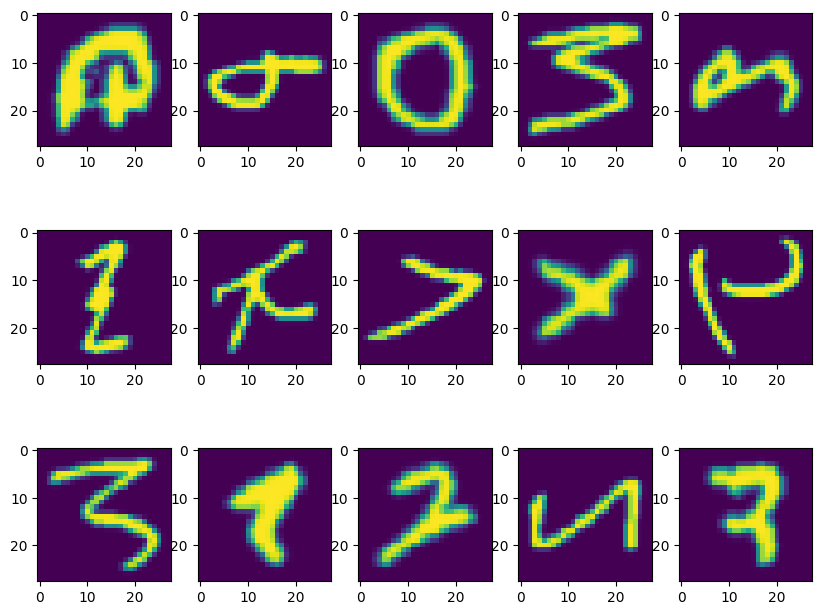

In [5]:
import matplotlib.pyplot as plt 
fig,axes = plt.subplots(3,5,figsize=(10,8))
for i,ax in enumerate(axes.flat):
    ax.imshow(x1[i].reshape([28,28]))

In [6]:
import tensorflow as tf

2026-05-27 04:54:56.960760: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779857697.146028      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779857697.201435      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779857697.650539      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779857697.650572      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779857697.650574      57 computation_placer.cc:177] computation placer alr

In [7]:
# Normalise and reshape data
train_images = x1 / 255.0
test_images = x2 / 255.0

train_images_number = train_images.shape[0]
train_images_height = 28
train_images_width = 28
train_images_size = train_images_height*train_images_width

train_images = train_images.reshape(train_images_number, train_images_height, train_images_width, 1)

test_images_number = test_images.shape[0]
test_images_height = 28
test_images_width = 28
test_images_size = test_images_height*test_images_width

test_images = test_images.reshape(test_images_number, test_images_height, test_images_width, 1)

In [8]:
# Transform labels
number_of_classes = 37

y1 = tf.keras.utils.to_categorical(y1, number_of_classes)
y2 = tf.keras.utils.to_categorical(y2, number_of_classes)

In [10]:
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y = train_test_split(train_images,y1,test_size=0.2,random_state = 42, stratify=y1)

In [35]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
 
# ─────────────────────────────────────────
# 1. CUSTOM LAYER — Channel Attention (SE)
# ─────────────────────────────────────────
class ChannelAttention(layers.Layer):
    """Squeeze-and-Excitation channel attention."""
 
    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
 
    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(max(1, channels // self.reduction_ratio), activation="relu")
        self.fc2 = layers.Dense(channels, activation="sigmoid")
        self.reshape = layers.Reshape((1, 1, channels))
 
    def call(self, x):
        scale = self.gap(x)
        scale = self.fc1(scale)
        scale = self.fc2(scale)
        scale = self.reshape(scale)
        return x * scale
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction_ratio": self.reduction_ratio})
        return cfg
 
 
# ─────────────────────────────────────────
# 2. CUSTOM LOSS — Label Smoothing CE
# ─────────────────────────────────────────
class LabelSmoothingCrossEntropy(keras.losses.Loss):
    """Cross-entropy with label smoothing to reduce overconfidence."""
 
    def __init__(self, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.smoothing = smoothing
 
    def call(self, y_true, y_pred):
        num_classes = tf.cast(tf.shape(y_pred)[-1], tf.float32)
        y_true = tf.cast(y_true, tf.float32)
 
        # One-hot if sparse
        if len(y_true.shape) == 1 or (len(y_true.shape) == 2 and y_true.shape[-1] == 1):
            y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32),
                                tf.cast(num_classes, tf.int32))
 
        smooth_labels = y_true * (1.0 - self.smoothing) + self.smoothing / num_classes
        log_probs = tf.nn.log_softmax(y_pred, axis=-1)
        loss = -tf.reduce_sum(smooth_labels * log_probs, axis=-1)
        return tf.reduce_mean(loss)
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"smoothing": self.smoothing})
        return cfg
 
 
# ─────────────────────────────────────────
# 3. CUSTOM CALLBACK — Verbose Epoch Log
# ─────────────────────────────────────────
class TrainingMonitor(keras.callbacks.Callback):
    """Prints a summary, reduces LR on plateau, and saves best model based on loss or accuracy."""
 
    def __init__(self, patience=3, factor=0.5, min_lr=1e-6, filepath="best_weights.h5", monitor="val_accuracy"):
        super().__init__()
        self.patience  = patience
        self.factor    = factor
        self.min_lr    = min_lr
        self.filepath  = filepath
        self.monitor   = monitor  # Can be "val_loss" or "val_accuracy"
        self._wait     = 0
        self.history   = []
        
        # Determine if we want to maximize or minimize the metric
        if "acc" in self.monitor:
            self._best = -np.inf  # Start at negative infinity for accuracy
            self._is_improvement = lambda current, best: current > best  # Higher is better
        else:
            self._best = np.inf   # Start at positive infinity for loss
            self._is_improvement = lambda current, best: current < best  # Lower is better
 
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get("val_loss", float("inf"))
        lr = float(self.model.optimizer.learning_rate)
 
        self.history.append({**logs, "lr": lr, "epoch": epoch + 1})
 
        # print(
        #     f"  Epoch {epoch+1:03d} | "
        #     f"loss={logs.get('loss', 0):.4f} | "
        #     f"acc={logs.get('accuracy', 0):.4f} | "
        #     f"val_loss={val_loss:.4f} | "
        #     f"val_acc={logs.get('val_accuracy', 0):.4f} | "
        #     f"lr={lr:.2e}"
        # )
 
        # Get the current value of the metric we are monitoring
        # (Defaults to 0 for accuracy, infinity for loss if missing)
        current_val = logs.get(self.monitor, 0.0 if "acc" in self.monitor else float("inf"))
        
        # Check for improvement using our dynamic lambda function
        if self._is_improvement(current_val, self._best):
            self._best = current_val
            self._wait = 0
            
            if self.model is not None:
                self.model.save_weights(self.filepath)
                print(f"  ★ New best {self.monitor}! Weights saved to {self.filepath}")
        else:
            self._wait += 1
            if self._wait >= self.patience:
                new_lr = max(lr * self.factor, self.min_lr)
                self.model.optimizer.learning_rate = new_lr
                print(f"  ↓ LR reduced → {new_lr:.2e}")
                self._wait = 0
 
    # def on_train_end(self, logs=None):
    #     print(f"\n  Training complete. Best {self.monitor}: {self._best:.4f}")
 
 
# ─────────────────────────────────────────
# 4. MISH ACTIVATION
# ─────────────────────────────────────────
def mish(x):
    return x * tf.math.tanh(tf.math.softplus(x))
 
 
# ─────────────────────────────────────────
# 5. CNN BLOCK BUILDER
# ─────────────────────────────────────────
def cnn_block(x, filters, activation_fn, block_id=0):
    """Conv → BN → Act → Conv → BN → Act → Pool → Dropout → Attention."""
    x = layers.Conv2D(filters, 3, padding="same", name=f"b{block_id}_conv1")(x)
    x = layers.BatchNormalization(name=f"b{block_id}_bn1")(x)
    x = layers.Activation(activation_fn, name=f"b{block_id}_act1")(x)
 
    x = layers.Conv2D(filters, 3, padding="same", name=f"b{block_id}_conv2")(x)
    x = layers.BatchNormalization(name=f"b{block_id}_bn2")(x)
    x = layers.Activation(activation_fn, name=f"b{block_id}_act2")(x)
 
    x = layers.MaxPooling2D(2, name=f"b{block_id}_pool")(x)
    x = layers.Dropout(0.25, name=f"b{block_id}_drop")(x)
    x = ChannelAttention(name=f"b{block_id}_attn")(x)
 
    return x
 
 
# ─────────────────────────────────────────
# 6. FULL MODEL — Functional API
# ─────────────────────────────────────────
def build_emnist_model(num_classes=37, input_shape=(28, 28, 1)):
    """
    5 CNN blocks — alternating Mish / ReLU:
      Block 1: Mish  | Block 2: ReLU  | Block 3: Mish
      Block 4: ReLU  | Block 5: Mish
    """
    cfg = [
        (32,  mish),
        (64,  keras.activations.get('relu')),
        (128, mish),
        (256, keras.activations.get('relu')),
        # (256, mish),
    ]
 
    inputs = keras.Input(shape=input_shape, name="input")
    x = inputs
 
    for i, (filters, act) in enumerate(cfg, start=1):
        x = cnn_block(x, filters, act, block_id=i)
 
    # Classifier head
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(512, name="fc1")(x)
    x = layers.Activation(mish, name="fc1_act")(x)
    x = layers.Dropout(0.5, name="fc1_drop")(x)
    x = layers.Dense(256, activation="relu", name="fc2")(x)
    x = layers.Dropout(0.3, name="fc2_drop")(x)
    outputs = layers.Dense(num_classes, name="logits")(x)   # raw logits
 
    return keras.Model(inputs, outputs, name="EMNIST_CNN")
 
 
# ─────────────────────────────────────────
# 7. COMPILE HELPER
# ─────────────────────────────────────────
def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=LabelSmoothingCrossEntropy(smoothing=0.1),
        metrics=["accuracy"],
    )
    return model
 
 
# ─────────────────────────────────────────
# 8. HISTORY PLOT
# ─────────────────────────────────────────
def plot_history(history):
    """
    Pass the Keras History object returned by model.fit().
    Saves 'training_history.png' and displays the plot.
    """
    h = history.history if hasattr(history, "history") else history
 
    epochs  = range(1, len(h["loss"]) + 1)
    TRAIN_C = "#00e5ff"
    VAL_C   = "#ff4081"
    GRID_C  = "#2a2a2a"
    TEXT_C  = "#e0e0e0"
 
    fig = plt.figure(figsize=(14, 5), facecolor="#0f0f0f")
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
 
    def styled_ax(pos, title, ylabel):
        ax = fig.add_subplot(pos)
        ax.set_facecolor("#1a1a1a")
        ax.set_title(title, color=TEXT_C, fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("Epoch", color=TEXT_C, fontsize=10)
        ax.set_ylabel(ylabel, color=TEXT_C, fontsize=10)
        ax.tick_params(colors=TEXT_C)
        ax.grid(True, color=GRID_C, linewidth=0.8, linestyle="--")
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_C)
        return ax
 
    ax1 = styled_ax(gs[0], "Loss", "Loss")
    ax1.plot(epochs, h["loss"],     color=TRAIN_C, lw=2, label="Train")
    ax1.plot(epochs, h["val_loss"], color=VAL_C,   lw=2, label="Val", linestyle="--")
    ax1.legend(facecolor="#2a2a2a", edgecolor=GRID_C, labelcolor=TEXT_C)
 
    ax2 = styled_ax(gs[1], "Accuracy", "Accuracy")
    ax2.plot(epochs, h["accuracy"],     color=TRAIN_C, lw=2, label="Train")
    ax2.plot(epochs, h["val_accuracy"], color=VAL_C,   lw=2, label="Val", linestyle="--")
    ax2.legend(facecolor="#2a2a2a", edgecolor=GRID_C, labelcolor=TEXT_C)
 
    fig.suptitle("EMNIST CNN — Training History", color=TEXT_C,
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    # plt.savefig("training_history.png", dpi=150, bbox_inches="tight",
    #             facecolor=fig.get_facecolor())
    plt.show()
    # print("Saved → training_history.png")

In [36]:
model   = build_emnist_model(num_classes=number_of_classes)
model   = compile_model(model, learning_rate=1e-3)
model.summary()

Model: "EMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_act1 (Activation)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_act2 (Activation)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_drop (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_attn (ChannelAttention)      │ (None, 14, 14, 32)     │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_act1 (Activation)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv2 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_act2 (Activation)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_drop (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_attn (ChannelAttention)      │ (None, 7, 7, 64)       │         1,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_act1 (Activation)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv2 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_act2 (Activation)            │ (None, 7, 7, 128)      │             

 Total params: 1,470,241 (5.61 MB)

 Trainable params: 1,468,321 (5.60 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5467 - loss: 1.9872  ★ New best val_accuracy! Weights saved to my_best_w.weights.h5
555/555 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.5471 - loss: 1.9861 - val_accuracy: 0.9044 - val_loss: 0.9567
Epoch 2/30
552/555 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9087 - loss: 0.9585  ★ New best val_accuracy! Weights saved to my_best_w.weights.h5
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9087 - loss: 0.9584 - val_accuracy: 0.9368 - val_loss: 0.8487
Epoch 3/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9285 - loss: 0.8961  ★ New best val_accuracy! Weights saved to my_best_w.weights.h5
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9285 - loss: 0.8961 - val_accuracy: 0.9448 - val_loss: 0.8198
Epoch 4/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9368 - loss: 0.8682 - val_accuracy: 0.9437 - val_loss: 0.8205
Epoch 5/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy

/tmp/ipykernel_57/3292066933.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


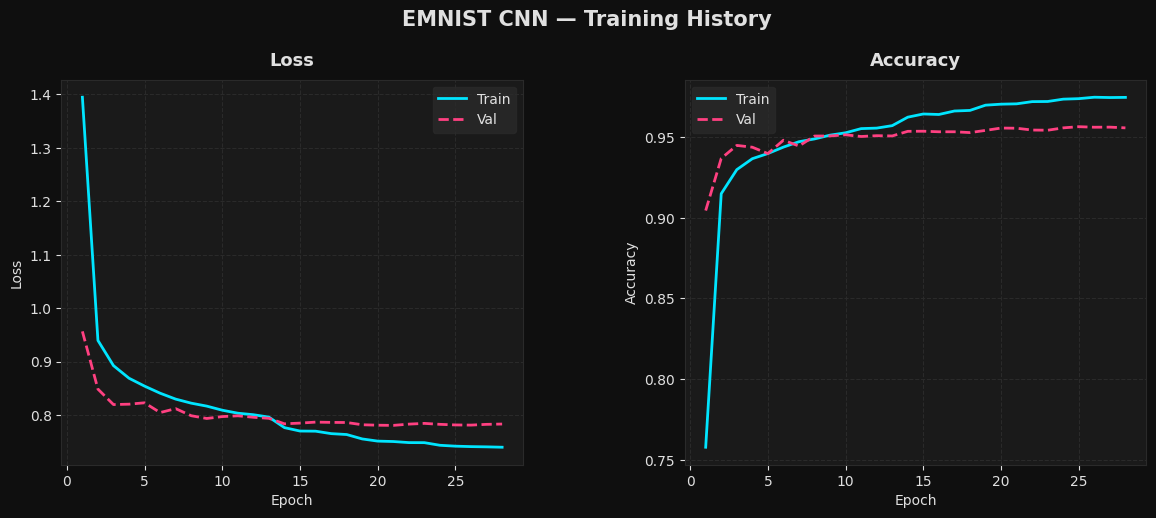

In [37]:
monitor = TrainingMonitor(patience=3, factor=0.5, filepath="my_best_w.weights.h5")

history = model.fit(
    train_x, train_y,
    validation_data=(test_x, test_y),
    epochs=30,
    batch_size=128,
    verbose=1,
    callbacks=[monitor,
               keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True)],
)

plot_history(history)

In [45]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# 1. Rebuild the model architecture exactly as before
model = build_emnist_model(num_classes=37, input_shape=(28, 28, 1))

# 2. Load your best saved weights
# Make sure the filename matches what you used during training!
model.load_weights("/kaggle/working/my_best_w.weights.h5")
print("★ Successfully loaded best model weights.")

from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf

# ── Inference ──────────────────────────────────────────
logits = model.predict(test_x, batch_size=128)
preds  = np.argmax(logits, axis=-1)
labels = np.argmax(test_y, axis=-1) if test_y.ndim == 2 else test_y.ravel().astype(int)

# ── Classification Report ───────────────────────────────
print(classification_report(labels, preds))

★ Successfully loaded best model weights.
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
              precision    recall  f1-score   support

           1       0.97      0.97      0.97       679
           2       0.99      0.99      0.99       679
           3       0.99      0.98      0.98       684
           4       0.97      0.98      0.98       680
           5       0.98      0.98      0.98       687
           6       0.98      0.99      0.98       679
           7       0.94      0.88      0.91       677
           8       0.97      0.98      0.98       685
           9       0.74      0.82      0.78       686
          10       0.95      0.96      0.96       680
          11       0.99      0.99      0.99       688
          12       0.81      0.71      0.76       683
          13       0.99      0.99      0.99       680
          14       0.98      0.97      0.98       673
          15       0.98      0.99      0.98       682
          16       0.99      0.98      0.98       6